# Troubleshooting

Your circuit isn't doing what you expect? Don't panic and don't start rewiring everything at once. When something goes wrong on ALPACA, the problem almost always lives in **one of four places**:

| Suspect | What it does | How you test it |
|---------|--------------|-----------------|
| <font color="#1b8700">**Power**</font> | Supplies voltage to your circuit from the Energy Hub | Measure every rail with the `VOLT` voltmeter |
| <font color="#ea9943">**Signal reading (ADC)**</font> | Turns a voltage into a number in your code | Read a **known** voltage from a potentiometer |
| <font color="#9e5508">**Signal output (DAC)**</font> | Turns a number in your code into a voltage | Connect it **directly** to the ADC and sweep the voltage |
| <font color="#7000ba">**Your components**</font> | The circuit you built on the Sandbox | Check every part and every node one by one |

The trick is to **test each suspect on its own with something you already know the answer to**. If a test passes, cross that suspect off the list and move on to the next.

```{important}
Do the checks **in this order**. Each test relies on the ones before it: the ADC test needs working power, the DAC test uses the ADC to measure the DAC, and checking your components uses all of them. If you skip ahead, a broken ADC can make a perfectly fine DAC look broken.
```

## 1. Power

Nothing works without power, so this is always the first thing to check.

**Is the board on?**

- Is the **USB-C cable** plugged into the power port on the top left, and is the **ON/OFF switch** on?
- Does the screen light up? If not, check the `J502` jumper: with the jumper on **1&2** the board only powers on when the <font color="#2d91a0">Student Pico</font> is also connected to your computer (see [Getting Started](./_intro.ipynb#getting-started)).

**Is the Energy Hub on?**

The <font color="#1b8700">**Energy Hub**</font> pins only output voltage when **the switch above them is turned on**. This is the most common reason a circuit is "dead" while the rest of the board seems fine. When the rail is giving the voltage the LED should be bright.

**Are the rails giving the right voltage?**

Use the `VOLT` voltmeter (cycle to it with the **FUNCTION button**) and connect each Energy Hub pin to `VOLTMETER-IN`, one at a time:

| Pin | You should read |
|-----|-----------------|
| `+12V` | about +12V |
| `-12V` | about -12V |
| `+5V` | about +5V |
| `+3.3V` | about +3.3V |
| `GND` | 0V |

Measure **twice**: once with your circuit disconnected and once with it connected.

- **Wrong when disconnected:** the problem is the board's power itself. Ask a TA.
- **Correct when disconnected, but drops when your circuit is connected:** your circuit draws too much current, most likely because **something is shorted to GND** somewhere. Disconnect it immediately and go to [Your Components](#your-components).

```{danger}
Never connect a voltage pin directly to a **GND** pin. If a rail suddenly reads 0V after you connected your circuit, unplug it right away and look for a short.
```

## 2. Signal Reading (ADC)

To test the <font color="#ea9943">**ADC**</font> you feed it a voltage that you **already know** and check whether your code prints the same value. The easiest known voltage on ALPACA is a potentiometer: the **Uvar** knobs in the Playground output anything between 0V and 3.3V on their `Uvar` pin (see [Variable U](./sandbox_playground.ipynb#variable-u)).

### Setup

1. Connect the `Uvar` pin to `U+` of <font color="#ea9943">**ADC0**</font>.
2. Put the jumper between `U-` and `GNDA`, so that $U_\text{diff} = U_+$.
3. Set the switches to **Gain 1x**, **no attenuation** and **DC coupling**. Any other setting changes the voltage the ADC sees, which is exactly what we want to rule out.
4. Also connect the same `Uvar` pin to `VOLTMETER-IN` and select the `VOLT` screen. Now you have a **reference** to compare your code against.

### Test code

```python
@pico.task
def read_adc(channel, N=100):
    """Returns the average voltage of N samples on ADC0, ADC1 or ADC2"""
    from machine import ADC

    adc = ADC(26 + channel) # ADC0 = Pin 26, ADC1 = Pin 27, ADC2 = Pin 28

    total = 0
    for i in range(N):
        total += adc.read_u16()

    return total / N * 3.3 / 2**16

import time

# Print a reading every half second for 15 seconds
for i in range(30):
    print(f"ADC0: {read_adc(0):.3f} V")
    time.sleep(0.5)
```

While the loop runs, **slowly turn the Uvar knob** from one end to the other and compare the printed value with the voltmeter on the screen.

```{tip}
Averaging over `N` samples smooths out noise, so you are testing the ADC itself and not a single unlucky sample.
```

### What you should see

- Knob fully down: close to **0V**
- Knob halfway: somewhere in the middle, **matching the voltmeter**
- Knob fully up: the maximum, **clipped** at the top of the ADC's range
- The value changes **smoothly** as you turn, and always goes up when you turn the same way

Small differences of a few tens of mV with the voltmeter are normal.

### If it doesn't

| Symptom | Likely cause |
|---------|--------------|
| Always reads ~0V | Wrong pin number in `ADC(...)`, or the cable is on the wrong ADC |
| Jumps around randomly, even when you don't touch the knob | The input is **floating**: a loose cable, or the `U-` ↔ `GNDA` jumper is missing |
| Follows the knob, but the value is consistently too high or too low by a factor | Gain or attenuation switch is not on 1x |
| Stuck in the middle and doesn't follow slow changes | Coupling is set to **AC**, which blocks DC voltages |
| Reaches the maximum way too early | Gain is set higher than 1x |

```{admonition} Test all of them
:class: tip
Repeat the test for <font color="#ea9943">**ADC1**</font> (`read_adc(1)`) and <font color="#ea9943">**ADC2**</font> (`read_adc(2)`). If one channel fails while the others work, the problem is that channel's settings or cable, not your code.
```

Once the ADC reads the same as the voltmeter, you can **trust it as a measuring tool** for the next steps.

## 3. Signal Output (DAC)

Now that you trust your ADC, you can use it to check the <font color="#9e5508">**DAC**</font>. The idea is simple: **connect the DAC output directly to the ADC input**, step the DAC through a range of voltages (a *voltage sweep*), read every step back with the ADC and plot what you asked for against what you got.

### Setup

1. Connect <font color="#9e5508">**DAC A**</font> directly to `U+` of <font color="#ea9943">**ADC0**</font>, with **nothing else** in between.
2. Keep the `U-` ↔ `GNDA` jumper, **Gain 1x**, **no attenuation** and **DC coupling** from the ADC test.

### Test code

```python
@pico.task
def dac_sweep(channel, adc_channel, v_max, steps, N=50):
    """
    Steps the DAC from 0V to v_max and reads every step back with the ADC.
    Returns the list of measured voltages.
    """
    from dac import DAC
    from machine import ADC
    from utime import sleep_ms

    dac = DAC(channel, v_ref=3000, gain=1)
    adc = ADC(26 + adc_channel)

    measured = []

    for i in range(steps):
        dac.write(v_max * i / (steps - 1))
        sleep_ms(5) # Give the output a moment to settle

        total = 0
        for _ in range(N):
            total += adc.read_u16()

        measured.append(total / N * 3.3 / 2**16)

    dac.write(0) # Leave the output at 0V when done
    return measured


import numpy as np
import matplotlib.pyplot as plt

V_MAX = 2.9
STEPS = 50

v_set = np.linspace(0, V_MAX, STEPS)
v_measured = np.array(dac_sweep("A", 0, V_MAX, STEPS))

plt.plot(v_set, v_set, linestyle="dashed", color="gray", label="Ideal")
plt.plot(v_set, v_measured, marker=".", label="Measured")
plt.xlabel("DAC voltage set (V)")
plt.ylabel("ADC voltage measured (V)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Largest error:", np.max(np.abs(v_measured - v_set)), "V")
```

Notice that all the measuring happens in **one** call to ALPACA, which keeps the sweep fast (see [Dealing with data](./programming.ipynb#dealing-with-data)).

### Reading the graph

A healthy DAC gives a **straight line on top of the dashed ideal line**. If your graph looks different, its shape tells you what is wrong:

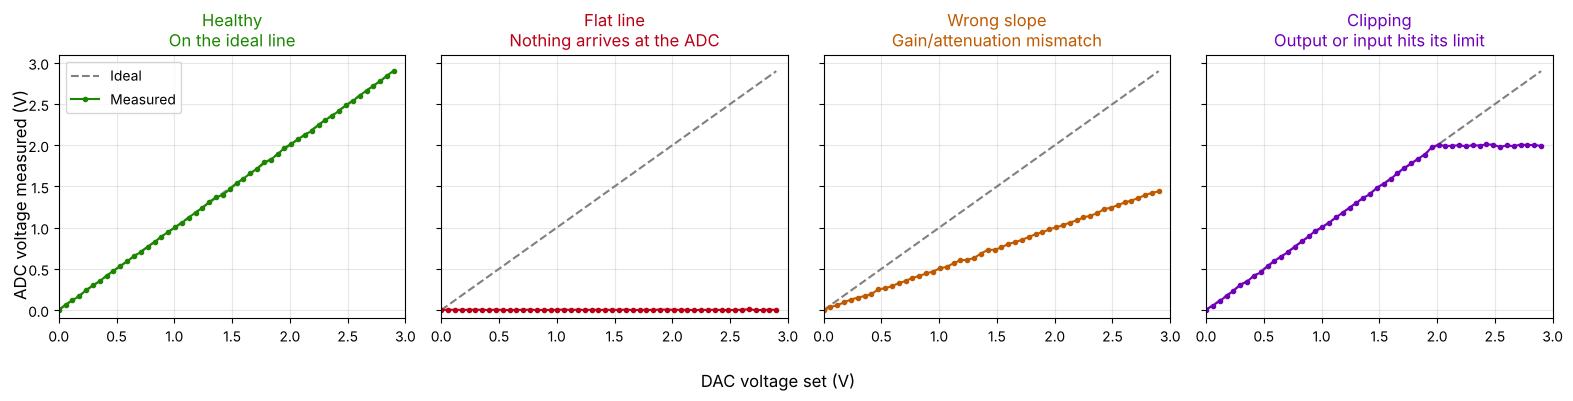

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
v = np.linspace(0, 2.9, 50)
noise = lambda: rng.normal(0, 0.008, v.size)

cases = [
    ("Healthy", v + noise(), "#1b8700",
     "On the ideal line"),
    ("Flat line", np.abs(noise()) * 0.5, "#bb0016",
     "Nothing arrives at the ADC"),
    ("Wrong slope", 0.5 * v + noise(), "#c05a00",
     "Gain/attenuation mismatch"),
    ("Clipping", np.minimum(v, 2.0) + noise(), "#7000ba",
     "Output or input hits its limit"),
]

fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for ax, (title, y, color, sub) in zip(axs, cases):
    ax.plot(v, v, linestyle="dashed", color="gray", label="Ideal")
    ax.plot(v, y, marker=".", color=color, label="Measured")
    ax.set_title(f"{title}\n{sub}", color=color)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 3)
    ax.set_ylim(-0.1, 3.1)

axs[0].legend(loc="upper left")
fig.supxlabel("DAC voltage set (V)")
fig.supylabel("ADC voltage measured (V)")
fig.tight_layout()
plt.show()

| What your graph looks like | Likely cause |
|----------------------------|--------------|
| **On the ideal line** | Your DAC works! The problem is elsewhere. |
| **Flat line at 0V** | The cable isn't connected to the right DAC/ADC pin, the channel name in `DAC("A")` doesn't match the pin you used, or the DAC wasn't written to |
| **Straight, but wrong slope** | The ADC's gain/attenuation switch isn't on 1x, or the DAC `gain` doesn't match what you expected |
| **Follows the line, then goes flat** | Clipping: you asked for more than the DAC's $V_\text{ref}$ or more than the ADC can read |
| **Line shifted up or down** | `U-` isn't connected to `GNDA`, so the ADC measures relative to something else |
| **Random jumps or steps** | Loose cable or bad contact; wiggle the cable and run the sweep again |

```{tip}
Repeat the sweep for **DAC B** (`dac_sweep("B", 0, ...)`). For AC signals, check the output on the oscilloscope as well (see [Connecting to oscilloscope](./sandbox_playground.ipynb#connecting-to-oscilloscope)), because a sweep is too slow to show how your waveform behaves at higher frequencies.
```

Once both the ADC and DAC pass their tests, you know that **ALPACA itself is working**. What's left is your circuit.

(your-components)=
## 4. Your Components

If the power, ADC and DAC all work, the problem is in the circuit you built. Work through it **from the source to the output**, checking one thing at a time.

### Check each component

Take suspicious parts out of the circuit and put them on the `COMPONENT-TESTER` plates (`COMP` screen):

- **Resistors:** is the value what you think it is? Color bands are easy to misread.
- **Diodes and LEDs:** which way does it conduct? A diode the wrong way round blocks everything.
- **Capacitors:** is the value right, and for electrolytic capacitors, is the polarity right?
- **Cables:** jumper wires break on the inside without you seeing it. A good cable on the component tester reads close to 0Ω; swap any cable you don't trust.

### Check the circuit, node by node

Draw your circuit and **calculate the voltage you expect at each node** (Ohm's law and voltage dividers will get you a long way). Then measure each node with the `VOLT` voltmeter or with your (now trusted) ADC, starting at the source and moving toward the output.

**The first node where your measurement doesn't match your calculation is where the problem is.** It's either the component right before that node or the connection to it.

### Common mistakes

- Two legs of a component in the **same breadboard row**, so they are shorted together
- A cable one row off from where you meant to put it
- Forgetting to connect your circuit's ground to **GND** on ALPACA
- An op-amp or other chip with no power: is it connected to the `+12V` / `-12V` rails and is the Energy Hub switch on?
- No jumper on the switchable resistor, which gives you **1MΩ** instead of the value you wanted
- A signal outside the range of what you are reading it with, for example a 5V signal straight into an ADC set to 1x gain

```{admonition} Still stuck?
:class: note
Write down what you tested and what you measured at each step. That turns "it doesn't work" into "everything checks out until this node", which makes it much quicker for a TA (or you!) to find the problem.
```